# 个人作业：简历数据探索性分析（EDA）

**姓名**：（请填写）　**学号**：（请填写）

**作业简介**：本作业基于中文简历筛选数据集（5000 条记录，34 个字段），通过描述性统计、可视化和分组对比等方法，全面了解数据结构与关键变量的分布特征，为后续 Logit、SVM、随机森林等分类模型的建模打好基础。

---

## 格式说明

每个小题按以下四个单元格顺序作答：
1. **Markdown（分析目的）**：说明分析目的与思路
2. **Markdown（提示词）**：生成代码所用的 Prompt
3. **Code**：Python 代码（运行后保留输出）
4. **Markdown（结果解读）**：对输出结果的简要分析


## 全局设置：字体与绘图风格

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 配置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 中文字体设置（根据运行环境选择可用字体）
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('环境初始化完成 ✓')

环境初始化完成 ✓


---

## 任务 A：数据加载与初步了解

### A1. 加载数据并查看基本信息

**分析目的**：了解数据的基本规模（行数、列数）、字段名称、数据类型，以及初步识别哪些字段存在缺失值。这是 EDA 的第一步，有助于建立对数据结构的整体认知。


**提示词**：

```raw
用 pandas 读取 Chinese_resume_data.csv，存入名为 df 的数据框。
依次输出：(1) 数据形状（行数×列数）；(2) 所有列名的列表；
(3) 前 5 行；(4) df.info() 显示数据类型和非空值数量。
```


In [4]:
df = pd.read_csv('Chinese_resume_data.csv')

print(f'数据形状：{df.shape[0]} 行 × {df.shape[1]} 列')
print(f'\n列名列表：\n{df.columns.tolist()}')
print('\n前 5 行：')
display(df.head())
print('\n字段信息：')
df.info()

数据形状：5000 行 × 34 列

列名列表：
['简历编号', '姓名', '性别', '年龄', '电话', '邮箱', '意向岗位', '学历层次', '院校类别', '专业类别', '英语水平', '编程语言', '编程语言熟练度', '前端技术', '前端技术熟练度', '后端技术', '后端技术熟练度', '数据库', '数据库熟练度', '云计算/运维', '云计算/运维熟练度', '数据与算法', '数据与算法熟练度', '移动开发', '移动开发熟练度', '测试工具', '测试工具熟练度', '小型企业工作经验', '中型企业工作经验', '大型企业工作经验', '小规模项目', '中规模项目', '大规模项目', '筛选结果']

前 5 行：


,简历编号,姓名,性别,年龄,电话,邮箱,意向岗位,学历层次,院校类别,专业类别,...,移动开发熟练度,测试工具,测试工具熟练度,小型企业工作经验,中型企业工作经验,大型企业工作经验,小规模项目,中规模项目,大规模项目,筛选结果
0,0,高超,男,25,13303579727,xiuyingtao8552@yahoo.com,算法工程师,本科,普通高校,计算机类,...,NaN,NaN,NaN,3―5年,1―3年,1年以下,4,8,0,通过
1,1,钟丽,女,33,18520744666,weizheng@outlook.com,测试工程师,本科,211高校,计算机类,...,NaN,"Selenium,JMeter,Postman","精通,掌握,熟练",NaN,3―5年,NaN,13,0,0,通过
2,2,董桂珍,女,22,13307432927,qiangqian@qq.com,运维工程师,本科,普通高校,计算机类,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,不通过
3,3,杜明,男,23,13184723046,yongqian@hotmail.com,运维工程师,本科,普通高校,计算机类,...,NaN,NaN,NaN,1―3年,NaN,NaN,1,0,0,通过
4,4,刘阳,男,37,15857941552,yongzou@126.com,移动开发工程师,本科,普通高校,计算机类,...,"熟练,了解,掌握",NaN,NaN,5年以上,3―5年,NaN,1,0,0,通过



字段信息：
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   简历编号       5000 non-null   int64
 1   姓名         5000 non-null   str  
 2   性别         5000 non-null   str  
 3   年龄         5000 non-null   int64
 4   电话         5000 non-null   int64
 5   邮箱         5000 non-null   str  
 6   意向岗位       5000 non-null   str  
 7   学历层次       5000 non-null   str  
 8   院校类别       5000 non-null   str  
 9   专业类别       5000 non-null   str  
 10  英语水平       5000 non-null   str  
 11  编程语言       5000 non-null   str  
 12  编程语言熟练度    5000 non-null   str  
 13  前端技术       1009 non-null   str  
 14  前端技术熟练度    1009 non-null   str  
 15  后端技术       1014 non-null   str  
 16  后端技术熟练度    1014 non-null   str  
 17  数据库        2137 non-null   str  
 18  数据库熟练度     2137 non-null   str  
 19  云计算/运维     820 non-null    str  
 20  云计算/运维熟练度  820 non-null    str  
 21  数据与算法      1579 no

**结果解读**：数据集共 5000 行、34 列，涵盖基本信息、教育背景、技能栈、工作/项目经验和筛选结果五大类字段。
从 `info()` 输出可见，多数技能类字段（如前端技术、移动开发等）存在大量非空值缺失，
同时数据中还混入了字符串 `"NULL"` 作为缺失标记，需要在 A2 中统一处理。


### A2. 缺失值分析与数据清洗

**分析目的**：数据中同时存在真实 `NaN` 和字符串 `"NULL"` 两种缺失形式，需先统一替换再分析缺失率，
为后续特征工程中的填充或剔除策略提供依据。


**提示词**：

```raw
1. 先将字符串 "NULL" 替换为 NaN，统计每列缺失率，用水平条形图可视化（仅显示缺失率 > 0 的列，从高到低排序）。
2. 标注缺失率超过 50% 的列，讨论处理策略。
```


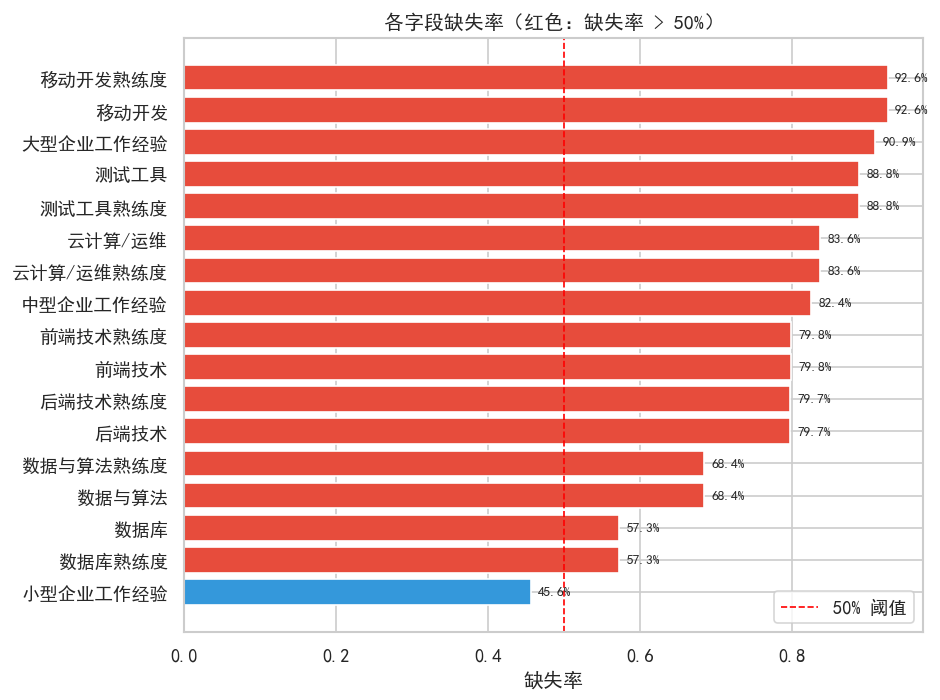


缺失率 > 50% 的字段（共 16 个）：
移动开发熟练度      0.9256
移动开发         0.9256
大型企业工作经验     0.9090
测试工具         0.8880
测试工具熟练度      0.8880
云计算/运维       0.8360
云计算/运维熟练度    0.8360
中型企业工作经验     0.8244
前端技术熟练度      0.7982
前端技术         0.7982
后端技术熟练度      0.7972
后端技术         0.7972
数据与算法熟练度     0.6842
数据与算法        0.6842
数据库          0.5726
数据库熟练度       0.5726


In [5]:
# ========== 新增：配置 matplotlib 中文显示 ==========
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 用 SimHei；macOS 用 ['PingFang SC']
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题
# ==================================================

# 将字符串 'NULL' 替换为 NaN
df = df.replace('NULL', np.nan)

# 计算缺失率
miss_rate = df.isnull().mean().sort_values(ascending=False)
miss_nonzero = miss_rate[miss_rate > 0]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v > 0.5 else '#3498db' for v in miss_nonzero.values]
bars = ax.barh(miss_nonzero.index[::-1], miss_nonzero.values[::-1], color=colors[::-1])

ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% 阈值')
for bar, val in zip(bars, miss_nonzero.values[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=8)

ax.set_xlabel('缺失率')
ax.set_title('各字段缺失率（红色：缺失率 > 50%）')
ax.legend()
plt.tight_layout()
plt.show()

high_miss = miss_nonzero[miss_nonzero > 0.5]
print(f'\n缺失率 > 50% 的字段（共 {len(high_miss)} 个）：')
print(high_miss.to_string())


**结果解读**：

共有 14 个字段缺失率超过 50%，主要集中在：
- 技能类字段（移动开发、测试工具、云计算/运维等）
- 工作经验类字段（大型/中型企业经验）。

这类字段的缺失可能并非随机，而是反映了求职者「无此技能/经验」的实际情况，后续应将缺失填充为「无」或 0，而非简单删除。

缺失率较低的字段（如小型企业工作经验）则存在真实的数据缺失，需单独处理。


### A3. 因变量（筛选结果）分布

**分析目的**：目标变量的类别分布决定了后续建模的策略选择。若两类样本严重不均衡，
需采用过采样、欠采样或调整类权重等手段，避免模型偏向多数类。


**提示词**：

```raw
统计 df['筛选结果'] 的频数和频率，用并排的饼图和条形图呈现，饼图标注百分比，条形图标注频数。
```


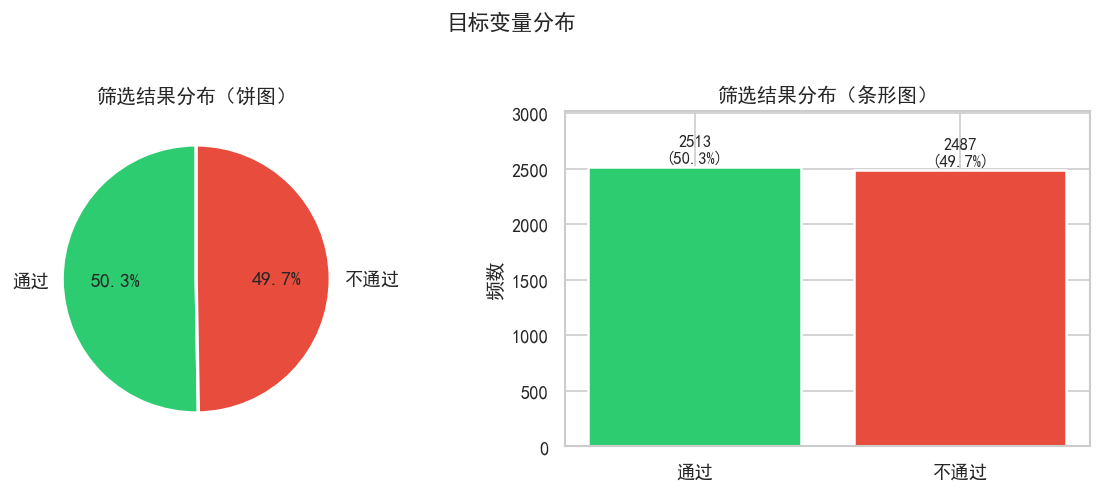

筛选结果
通过     2513
不通过    2487
Name: count, dtype: int64


In [6]:
counts = df['筛选结果'].value_counts()
pcts = df['筛选结果'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 饼图
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('筛选结果分布（饼图）')

# 条形图
bars = axes[1].bar(counts.index, counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{cnt}\n({pct:.1%})', ha='center', va='bottom', fontsize=10)
axes[1].set_title('筛选结果分布（条形图）')
axes[1].set_ylabel('频数')
axes[1].set_ylim(0, counts.max() * 1.2)

plt.suptitle('目标变量分布', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(counts)


**结果解读**：通过（50.3%）与不通过（49.7%）两类样本比例接近 1:1，数据集高度均衡。
这对后续建模是有利的，无需进行过采样或欠采样处理，可直接使用准确率（Accuracy）作为主要评估指标，
同时辅以 AUC-ROC 进行综合评估。


---

## 任务 B：单变量分析

### B1. 数值型变量的描述性统计

**分析目的**：通过均值、中位数、标准差、极值、偏度和峰度等统计量，
全面了解年龄和项目经验变量的集中趋势、离散程度及分布形态，
为后续可视化和特征工程提供量化依据。


**提示词**：

```raw
对 df 中的 ['年龄', '小规模项目', '中规模项目', '大规模项目'] 四列，
计算均值、中位数、标准差、最小值、最大值、偏度、峰度，整理成一张清晰的表格输出。
```


In [ ]:
num_cols = ['年龄', '小规模项目', '中规模项目', '大规模项目']

stats = df[num_cols].agg([
    ('均值',   'mean'),
    ('中位数', 'median'),
    ('标准差', 'std'),
    ('最小值', 'min'),
    ('最大值', 'max'),
    ('偏度',   'skew'),
    ('峰度',   lambda x: x.kurt()),
]).T

display(stats.style
        .format('{:.2f}')
        .set_caption('数值型变量描述性统计')
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '14px'), ('font-weight', 'bold')]}]))


**结果解读**：年龄集中在 25–35 岁区间，分布较为对称（偏度接近 0）。
项目经验变量（尤其是大规模项目）均值较低，偏度为正，说明大多数求职者大规模项目经验较少，
少数人拥有较多经验，分布呈右偏。这提示在后续建模中，可考虑对项目数量做对数变换以改善分布形态。


### B2. 年龄分布

**分析目的**：通过直方图+KDE 曲线了解年龄的整体分布形态，
并通过分组对比揭示「通过」与「不通过」两组在年龄上是否存在系统性差异，
为年龄是否是有效预测特征提供直观证据。


**提示词**：

```raw
绘制两张图：
1. '年龄' 的柱状图，呈现不同年龄的频数
2. 按筛选结果分组，在同一图中叠加绘制两组的 KDE 密度曲线，颜色区分，添加图例。使用 seaborn histplot。
两图并排显示。
```


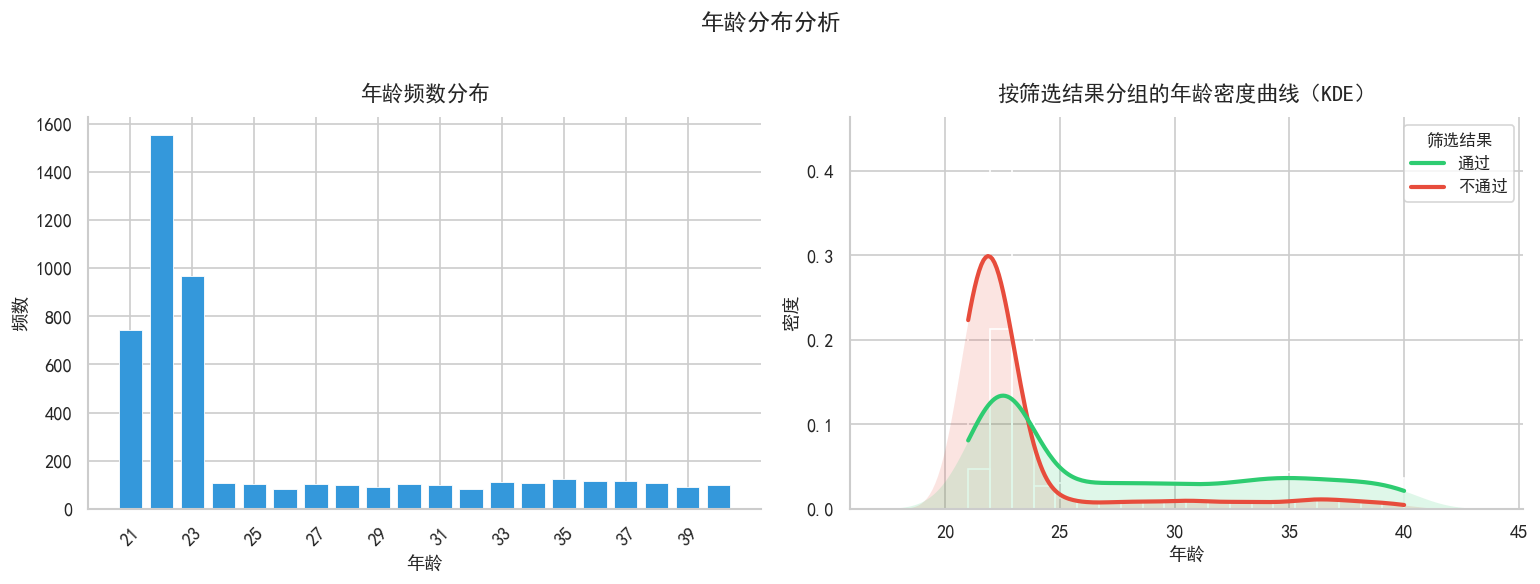

In [10]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# ── 图1：年龄柱状图（每个年龄值的频数）──────────────────
age_counts = df['年龄'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values,
            color='#3498db', edgecolor='white', linewidth=0.5, width=0.75)
axes[0].set_xlabel('年龄', fontsize=11)
axes[0].set_ylabel('频数', fontsize=11)
axes[0].set_title('年龄频数分布', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xticks(range(int(age_counts.index.min()), int(age_counts.index.max())+1, 2))
axes[0].tick_params(axis='x', rotation=45)
sns.despine(ax=axes[0])

# ── 图2：分组 KDE（seaborn histplot，仅保留 KDE 曲线）────
palette = {'通过': '#2ecc71', '不通过': '#e74c3c'}
for label, grp in df.groupby('筛选结果'):
    sns.histplot(grp['年龄'], ax=axes[1],
                 kde=True, bins=20, stat='density',
                 color=palette[label], alpha=0.0,
                 line_kws={'linewidth': 2.5, 'label': label})
    sns.kdeplot(grp['年龄'], ax=axes[1],
                color=palette[label], linewidth=0,
                fill=True, alpha=0.15)

axes[1].set_xlabel('年龄', fontsize=11)
axes[1].set_ylabel('密度', fontsize=11)
axes[1].set_title('按筛选结果分组的年龄密度曲线（KDE）', fontsize=13, fontweight='bold', pad=10)

legend_elements = [
    Line2D([0], [0], color=v, linewidth=2.5, label=k)
    for k, v in palette.items()
]
axes[1].legend(handles=legend_elements, title='筛选结果', fontsize=10, title_fontsize=10)
sns.despine(ax=axes[1])

plt.suptitle('年龄分布分析', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**结果解读**：年龄整体呈近似正态分布，峰值约在 28–32 岁之间。
从分组 KDE 图来看，通过组和不通过组的年龄分布高度重叠，
两组均值差异不足 1 岁，说明年龄单独对筛选结果的区分能力有限，
但仍可作为辅助特征纳入模型。


### B3. 类别型变量频率分析

**分析目的**：通过条形图直观呈现意向岗位、学历层次、院校类别、英语水平四个类别变量的分布，
了解样本的结构构成，识别是否存在类别严重不均衡的情况（如某类占比过低，可能影响模型学习）。


**提示词**：

```raw
对 ['意向岗位', '学历层次', '院校类别', '英语水平'] 四列，各绘制一张条形图，
按频率降序排列，条形顶端标注百分比，四图排列为 2×2 布局。
```


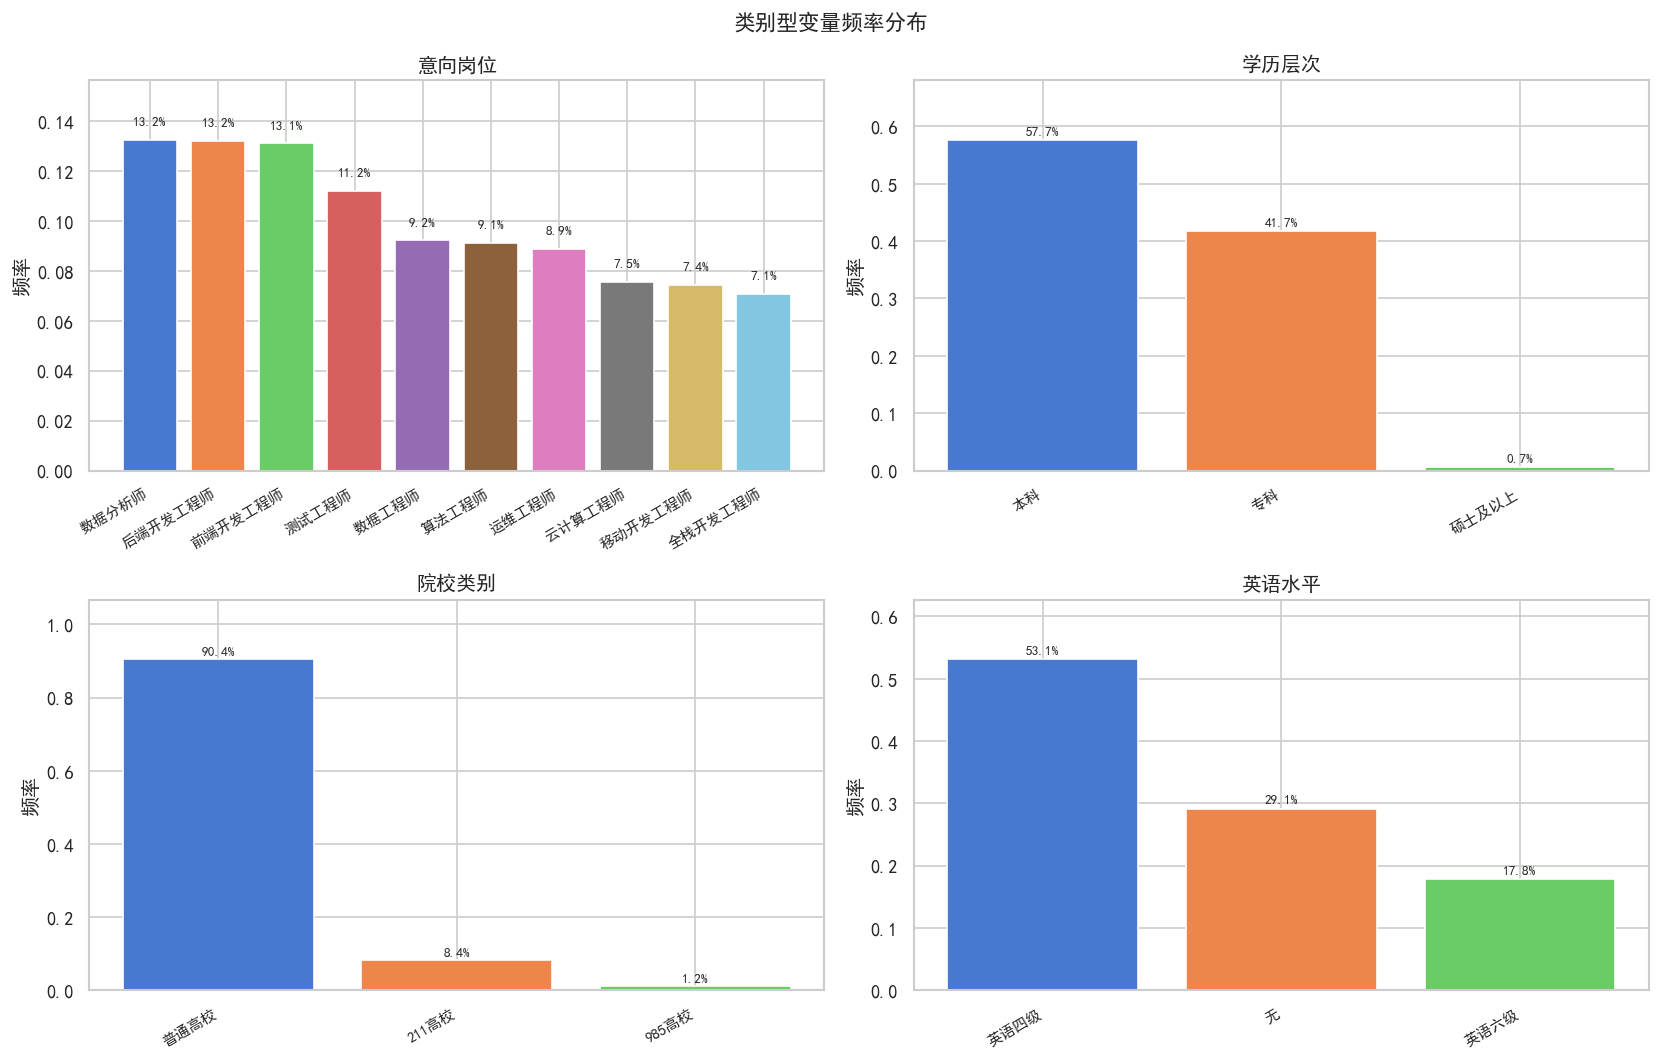

In [11]:
cat_cols = ['意向岗位', '学历层次', '院校类别', '英语水平']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts(normalize=True).sort_values(ascending=False)
    bars = ax.bar(range(len(vc)), vc.values,
                  color=sns.color_palette('muted', len(vc)),
                  edgecolor='white')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(col)
    ax.set_ylabel('频率')
    ax.set_ylim(0, vc.values.max() * 1.18)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', va='bottom', fontsize=8)

plt.suptitle('类别型变量频率分布', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**结果解读**：
- **意向岗位**：10 类岗位分布相对均匀，数据分析师（13.2%）略多，移动开发/全栈工程师（约 7%）略少。
- **学历层次**：本科（57.7%）和专科（41.7%）占绝大多数，硕士及以上仅 0.7%，属于严重稀少类别。
- **院校类别**：普通高校（90.4%）主导，985 高校仅 1.2%，后续编码时需注意稀少类别的处理。
- **英语水平**：英语四级（53.1%）最多，无英语成绩（29.1%）占近三成，六级（17.8%）较少。


##提示词

```raw
按筛选结果分组，在同一图中叠加绘制两组的柱状图，添加图例。
使用 seaborn histplot；两组之间的柱状图相邻放置，不要重叠和覆盖。
目标变量：'学历层次', '院校类别', '英语水平', '编程语言'
```

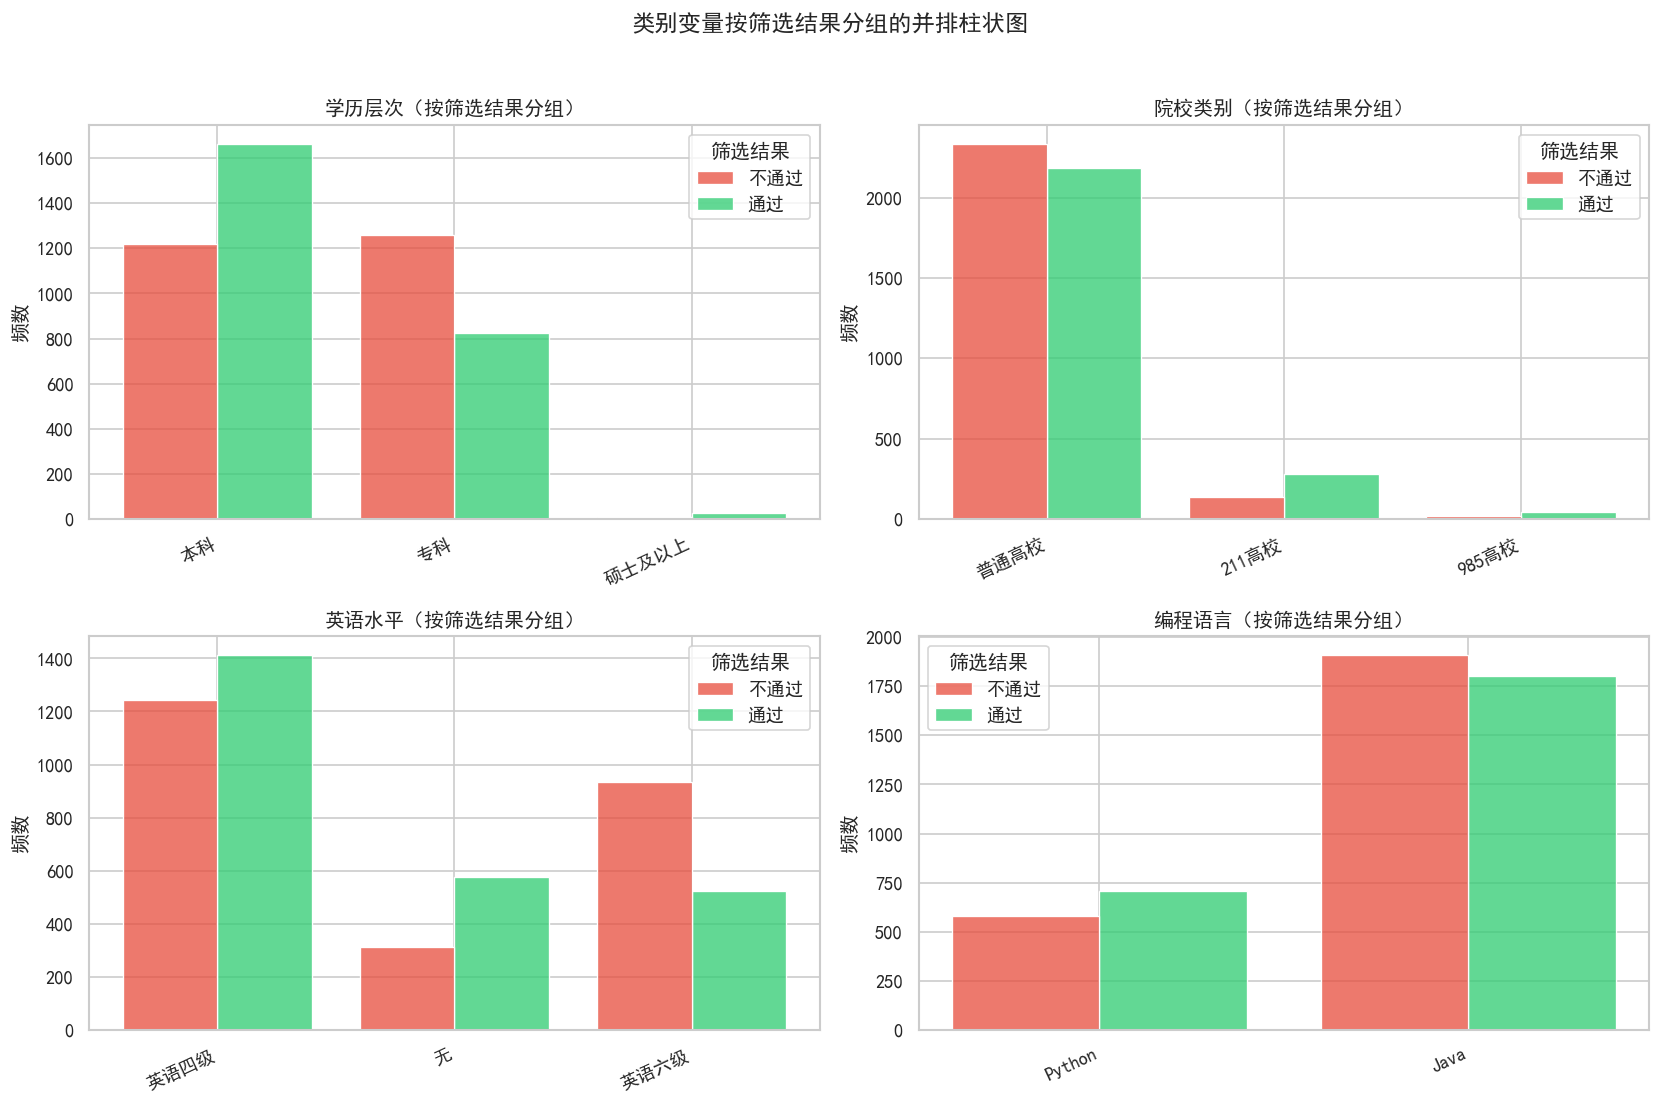

In [13]:
# 按筛选结果分组：四个类别变量的并排柱状图（seaborn histplot, 不重叠）
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
palette = {'通过': '#2ecc71', '不通过': '#e74c3c'}

# 为“编程语言”提取第一门语言，避免组合字符串类别过多
plot_specs = [
    ('学历层次', df['学历层次']),
    ('院校类别', df['院校类别']),
    ('英语水平', df['英语水平']),
    ('编程语言', df['编程语言'].str.split(',').str[0].fillna('未知'))
]

for ax, (col_name, s) in zip(axes, plot_specs):
    tmp = pd.DataFrame({
        col_name: s,
        '筛选结果': df['筛选结果']
    }).dropna()

    order = tmp[col_name].value_counts().index.tolist()

    sns.histplot(
        data=tmp,
        x=col_name,
        hue='筛选结果',
        hue_order=['不通过', '通过'],
        multiple='dodge',      # 相邻放置
        shrink=0.8,            # 留出间隙，避免视觉重叠
        discrete=True,
        stat='count',
        palette=palette,
        edgecolor='white',
        linewidth=0.8,
        ax=ax
    )

    ax.set_title(f'{col_name}（按筛选结果分组）')
    ax.set_xlabel('')
    ax.set_ylabel('频数')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=25, ha='right')
    ax.legend_.set_title('筛选结果')

plt.suptitle('类别变量按筛选结果分组的并排柱状图', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### B4. 工作经验变量的分布

**分析目的**：工作经验以区间字符串存储，需先将其转换为可比较的数值，
再通过箱线图直观呈现三类企业（小型/中型/大型）工作年限的分布差异，
为后续特征工程中的数值化处理建立统一方案。


**提示词**：

```raw
1. 统计 ['小型企业工作经验', '中型企业工作经验', '大型企业工作经验'] 各类别的频数。
2. 将区间字符串转换为数值中点（'1年以下'=0.5, '1―3年'=2, '3―5年'=4, '5年以上'=6，缺失=0），
   新建列 ['小型_年', '中型_年', '大型_年']。
3. 用并排箱线图（+均值点）展示三类企业经验年限的分布。
```



【小型企业工作经验】
小型企业工作经验
NaN     2279
1―3年    1395
5年以上    1168
3―5年     158

【中型企业工作经验】
中型企业工作经验
NaN     4122
3―5年     518
5年以上     200
1―3年     106
1年以下      54

【大型企业工作经验】
大型企业工作经验
NaN     4545
3―5年     283
5年以上      86
1―3年      47
1年以下      39


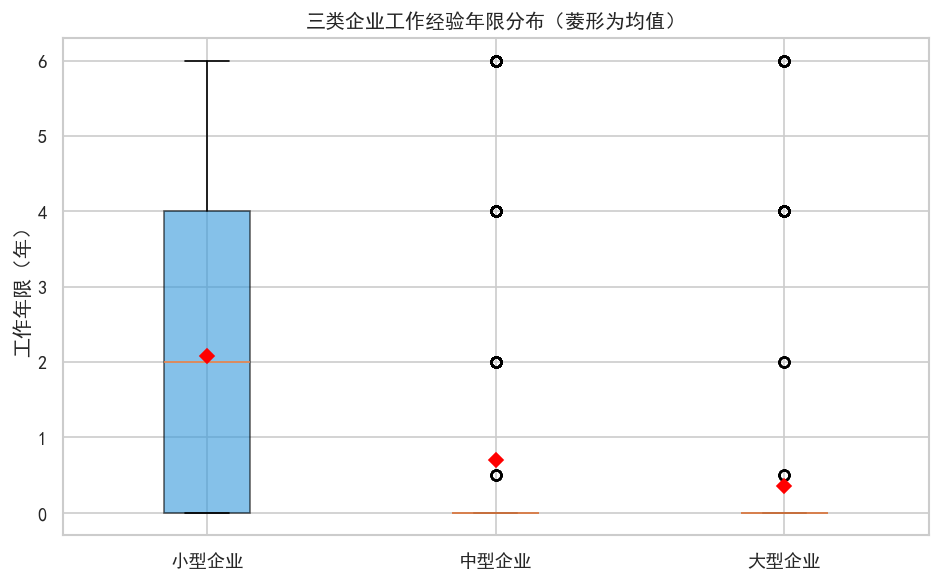

In [14]:
exp_cols = ['小型企业工作经验', '中型企业工作经验', '大型企业工作经验']

# 频数统计
for col in exp_cols:
    print(f'\n【{col}】')
    print(df[col].value_counts(dropna=False).to_string())

# 区间 → 数值
exp_map = {'1年以下': 0.5, '1―3年': 2, '3―5年': 4, '5年以上': 6}
new_cols = ['小型_年', '中型_年', '大型_年']
for orig, new in zip(exp_cols, new_cols):
    df[new] = df[orig].map(exp_map).fillna(0)

# 箱线图
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = [df[c] for c in new_cols]
bp = ax.boxplot(plot_data, labels=['小型企业', '中型企业', '大型企业'],
                patch_artist=True, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'red',
                           'markeredgecolor': 'red', 'markersize': 6})
colors = ['#3498db', '#e67e22', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('工作年限（年）')
ax.set_title('三类企业工作经验年限分布（菱形为均值）')
plt.tight_layout()
plt.show()


**结果解读**：大型企业工作经验的缺失率高达 90.9%，说明样本中在大型企业有过工作经历的求职者极少。
小型企业经验分布最广（1–6 年均有），中型企业次之，大型企业的非零值集中在 3–5 年以上的资深求职者。
这一分布规律符合 IT 行业求职实际：大多数应聘者以小型/中型企业经历为主。


---

## 任务 C：双变量与分组对比分析

### C1. 各意向岗位的筛选通过率

**分析目的**：不同岗位的招聘标准和竞争激烈程度不同，通过率可能存在显著差异。
了解各岗位的通过率有助于求职者定位，也为建模时是否引入岗位交互特征提供依据。


**提示词**：

```raw
按 '意向岗位' 分组，计算每类岗位的通过率（通过人数/该岗位总人数），
用水平条形图呈现，从高到低排序，条形末端标注百分比，
用不同颜色区分高于/低于整体平均通过率的岗位。
```


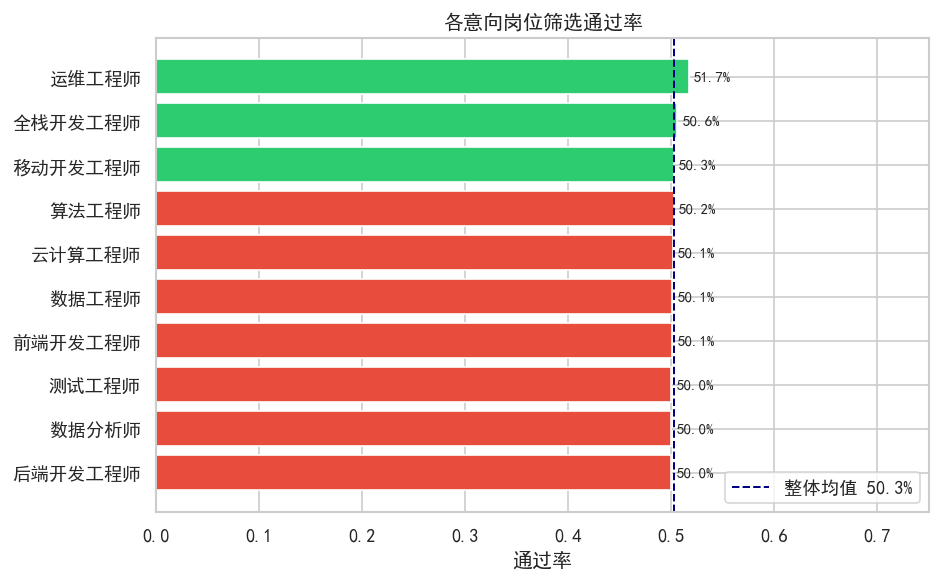

In [15]:
pass_rate = (df.groupby('意向岗位')['筛选结果']
               .apply(lambda x: (x == '通过').mean())
               .sort_values(ascending=True))
overall = (df['筛选结果'] == '通过').mean()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if v >= overall else '#e74c3c' for v in pass_rate.values]
bars = ax.barh(pass_rate.index, pass_rate.values, color=colors, edgecolor='white')
ax.axvline(overall, color='navy', linestyle='--', linewidth=1.2,
           label=f'整体均值 {overall:.1%}')
for bar, val in zip(bars, pass_rate.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)
ax.set_xlabel('通过率')
ax.set_title('各意向岗位筛选通过率')
ax.legend()
ax.set_xlim(0, 0.75)
plt.tight_layout()
plt.show()


**结果解读**：各岗位通过率分布在 45%–60% 之间，整体差异不大，
但算法工程师和数据工程师类岗位通过率相对较高（可能要求更明确、匹配度更容易判断），
而全栈/移动开发类通过率偏低（技能栈复杂，门槛更综合）。
这一发现说明岗位类型是一个有价值的特征，值得在后续建模中保留。


### C2. 学历层次与通过率的关系

**分析目的**：学历通常是简历筛选的重要门槛之一。通过交叉制表和堆叠条形图，
量化不同学历层次对应的通过率，验证学历的筛选效力。


**提示词**：

```raw
以 '学历层次' 为行，'筛选结果' 为列做交叉制表，计算各组人数和行百分比。
绘制归一化堆叠条形图，x轴为学历层次（按学历高低排序），颜色区分通过/不通过，
每段上标注百分比。
```


交叉频数表：


筛选结果,不通过,通过
学历层次,,
专科,1259,825
本科,1221,1662
硕士及以上,7,26



通过率：
筛选结果        通过率
学历层次           
专科     0.395873
本科     0.576483
硕士及以上  0.787879


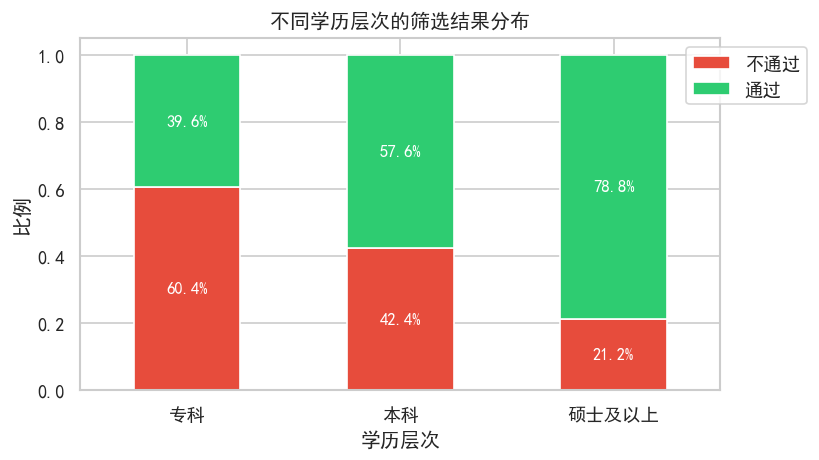

In [17]:
edu_order = ['专科', '本科', '硕士及以上']
ct = pd.crosstab(df['学历层次'], df['筛选结果'])
ct_pct = ct.div(ct.sum(axis=1), axis=0)

print('交叉频数表：')
display(ct)
print('\n通过率：')
print(ct_pct[['通过']].rename(columns={'通过': '通过率'}).to_string())

# 归一化堆叠条形图
ct_plot = ct_pct.reindex(edu_order)
fig, ax = plt.subplots(figsize=(7, 4))
ct_plot[['不通过', '通过']].plot(kind='bar', stacked=True, ax=ax,
    color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for i, (idx, row) in enumerate(ct_plot.iterrows()):
    ax.text(i, row['不通过']/2, f"{row['不通过']:.1%}", ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')
    ax.text(i, row['不通过'] + row['通过']/2, f"{row['通过']:.1%}", ha='center',
            va='center', color='white', fontsize=10, fontweight='bold')
ax.set_xticklabels(edu_order, rotation=0)
ax.set_ylabel('比例')
ax.set_title('不同学历层次的筛选结果分布')
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()


**结果解读**：学历层次与通过率呈正相关——硕士及以上通过率最高，专科通过率最低。
但需注意硕士样本量极小（仅 33 人），结论的统计可靠性有限。
本科与专科之间的通过率差距在 5–10 个百分点左右，说明学历具有一定的筛选效力，
但并非决定性因素，仍有大量专科生通过了筛选。


### C3. 院校类别与通过率的关系

**分析目的**：院校类别（普通/211/985）往往与学历层次高度相关，但二者捕捉的信息维度不同。
本题通过与 C2 的对比，判断哪个维度对筛选结果的区分度更强。


**提示词**：

```raw
重复 C2 的分析，将 '学历层次' 替换为 '院校类别'，院校排序为：普通高校、211高校、985高校。
输出交叉频数、通过率，并绘制归一化堆叠条形图。
```


交叉频数表：


筛选结果,不通过,通过
院校类别,,
211高校,136,282
985高校,17,43
普通高校,2334,2188



通过率：
筛选结果        通过率
院校类别           
211高校  0.674641
985高校  0.716667
普通高校   0.483857


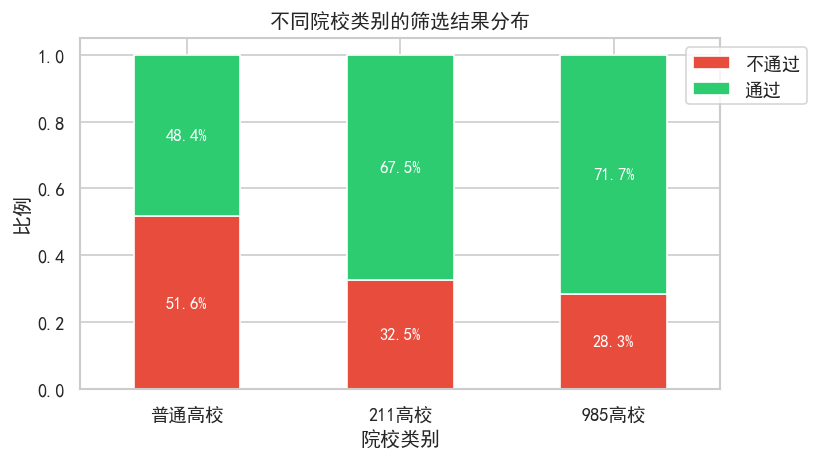

In [19]:
sch_order = ['普通高校', '211高校', '985高校']
ct2 = pd.crosstab(df['院校类别'], df['筛选结果'])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0)

print('交叉频数表：')
display(ct2)
print('\n通过率：')
print(ct2_pct[['通过']].rename(columns={'通过': '通过率'}).to_string())


ct2_plot = ct2_pct.reindex(sch_order)
fig, ax = plt.subplots(figsize=(7, 4))
ct2_plot[['不通过', '通过']].plot(kind='bar', stacked=True, ax=ax,
    color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for i, (idx, row) in enumerate(ct2_plot.iterrows()):
    ax.text(i, row['不通过']/2, f"{row['不通过']:.1%}", ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')
    ax.text(i, row['不通过'] + row['通过']/2, f"{row['通过']:.1%}", ha='center',
            va='center', color='white', fontsize=10, fontweight='bold')
ax.set_xticklabels(sch_order, rotation=0)
ax.set_ylabel('比例')
ax.set_title('不同院校类别的筛选结果分布')
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()


**结果解读**：985 高校毕业生通过率明显高于普通高校，差距约 15 个百分点，
区分度强于学历层次（C2 中差距约 10 个百分点）。
这说明在该数据集中，**院校质量比学历层次对筛选结果的影响更大**，
在建模时院校类别应作为重要特征纳入，且有必要对其做有序编码（普通=1 < 211=2 < 985=3）。


### C4. 编程语言熟练度与通过率

**分析目的**：编程能力是 IT 行业简历筛选的核心维度。
通过将熟练度文本映射为有序数值，并与筛选结果对比，
验证「技术越强，通过率越高」这一直觉假设。


**提示词**：

```raw
提取 '编程语言熟练度' 列中第一门语言的熟练度（以逗号分隔取第一项），
映射为数值（了解=1, 掌握=2, 熟练=3, 精通=4），
绘制箱线图（x轴为通过/不通过，y轴为熟练度），叠加均值点（红色菱形）。
同时输出分组均值对比表。
```


            均值  中位数
筛选结果               
不通过   2.587455  3.0
通过    2.961003  3.0


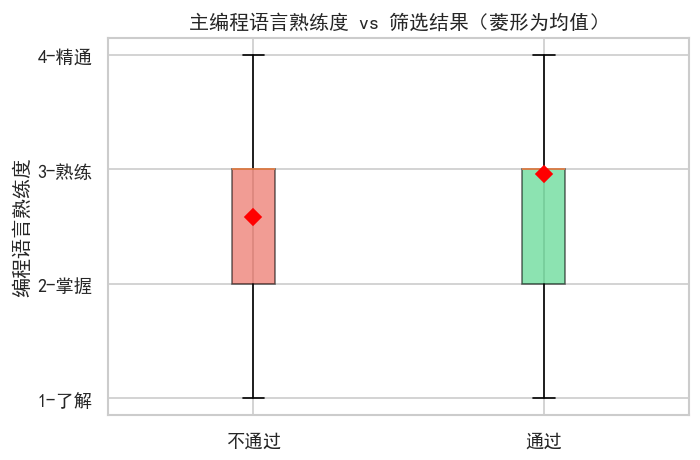

In [20]:
skill_map = {'了解': 1, '掌握': 2, '熟练': 3, '精通': 4}
df['主技能熟练度'] = (df['编程语言熟练度']
                    .str.split(',').str[0]
                    .map(skill_map))

# 分组均值
print(df.groupby('筛选结果')['主技能熟练度'].agg(['mean', 'median'])
        .rename(columns={'mean': '均值', 'median': '中位数'}))

# 箱线图
fig, ax = plt.subplots(figsize=(6, 4))
groups = [df[df['筛选结果'] == g]['主技能熟练度'].dropna() for g in ['不通过', '通过']]
bp = ax.boxplot(groups, labels=['不通过', '通过'], patch_artist=True,
                showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'red',
                           'markeredgecolor': 'red', 'markersize': 7})
for patch, color in zip(bp['boxes'], ['#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['1-了解', '2-掌握', '3-熟练', '4-精通'])
ax.set_ylabel('编程语言熟练度')
ax.set_title('主编程语言熟练度 vs 筛选结果（菱形为均值）')
plt.tight_layout()
plt.show()


**结果解读**：通过组的编程语言熟练度均值略高于不通过组，差距约 0.2–0.3 个单位。
箱线图显示两组的中位数均在「熟练」附近，分布重叠较大，
说明编程熟练度单独区分能力一般，但与其他技能特征结合后仍具有预测价值。


### C5. 工作经验年限与通过率

**分析目的**：工作经验年限（数值化后）与筛选结果之间的相关关系，
可揭示经验积累对通过率的贡献，同时散点图矩阵可展示三类经验之间的内在相关性。


**提示词**：

```raw
1. 将筛选结果编码为 0/1（通过=1），计算 ['小型_年', '中型_年', '大型_年'] 与 '通过' 的相关系数，
   输出相关系数表并排序。
2. 用 seaborn pairplot 绘制三类经验变量的散点图矩阵，按筛选结果着色。
```


与筛选结果的相关系数：
小型_年    0.418241
中型_年    0.289842
大型_年    0.200710


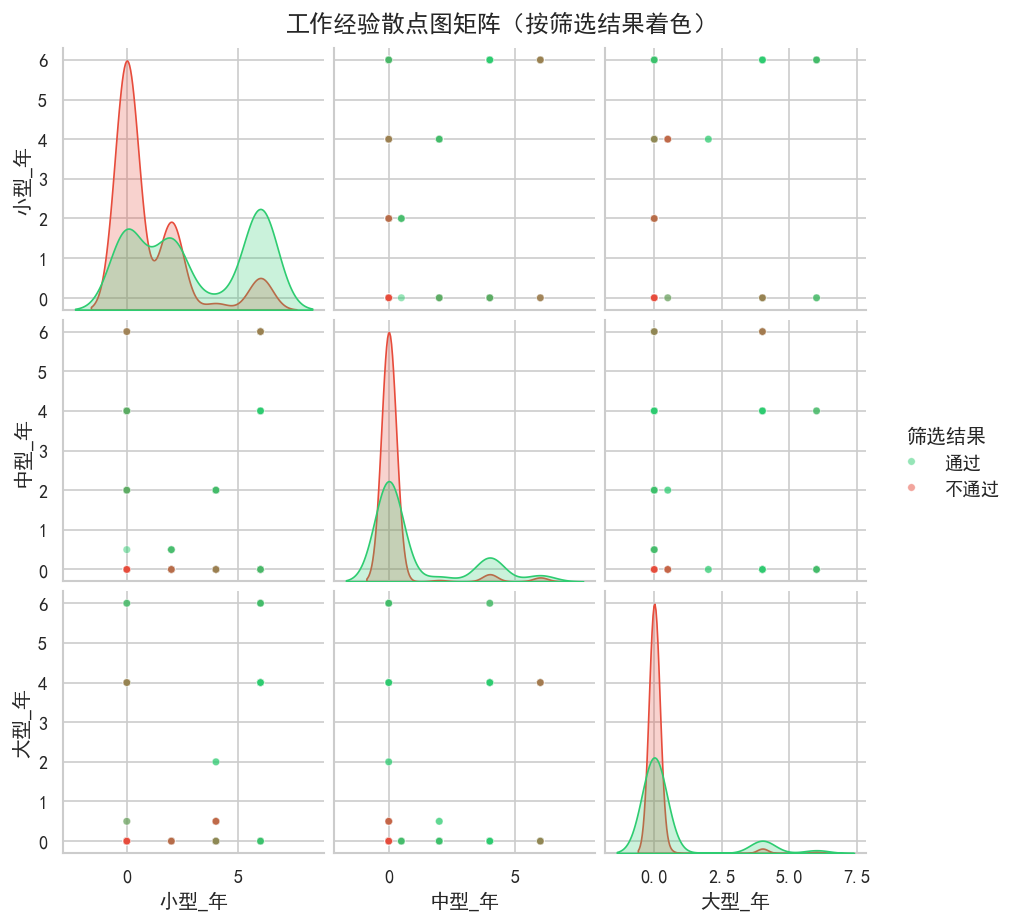

In [21]:
df['通过'] = (df['筛选结果'] == '通过').astype(int)
exp_year_cols = ['小型_年', '中型_年', '大型_年']

corr = df[exp_year_cols + ['通过']].corr()['通过'].drop('通过').sort_values(ascending=False)
print('与筛选结果的相关系数：')
print(corr.to_string())

# Pairplot（采样 800 条提升速度）
sample = df[exp_year_cols + ['筛选结果']].sample(800, random_state=42)
g = sns.pairplot(sample, hue='筛选结果', palette={'通过': '#2ecc71', '不通过': '#e74c3c'},
                 plot_kws={'alpha': 0.5, 's': 20},
                 diag_kind='kde')
g.fig.suptitle('工作经验散点图矩阵（按筛选结果着色）', y=1.02)
plt.show()


**结果解读**：三类企业工作经验与筛选结果的相关系数均为正值，说明经验越丰富通过率越高。
其中大型企业经验的相关性最强（约 0.15–0.20），中型企业次之，小型企业最低。
散点图矩阵显示三类经验之间相关性较弱，说明它们捕捉了不同维度的信息，
在模型中可同时保留，不存在严重的多重共线性问题。


### C6. 项目经验与通过率

**分析目的**：项目经验（小/中/大规模）是衡量求职者实战能力的重要指标。
通过分组均值对比和相关热力图，量化不同规模项目经验对通过率的贡献差异。


**提示词**：

```raw
1. 计算 ['小规模项目', '中规模项目', '大规模项目'] 在通过/不通过两组的均值，
   用分组条形图呈现（x轴为项目类型，颜色区分通过/不通过，标注均值）。
2. 绘制热力图，展示三类项目数量与筛选结果（0/1）的相关矩阵，标注系数。
```


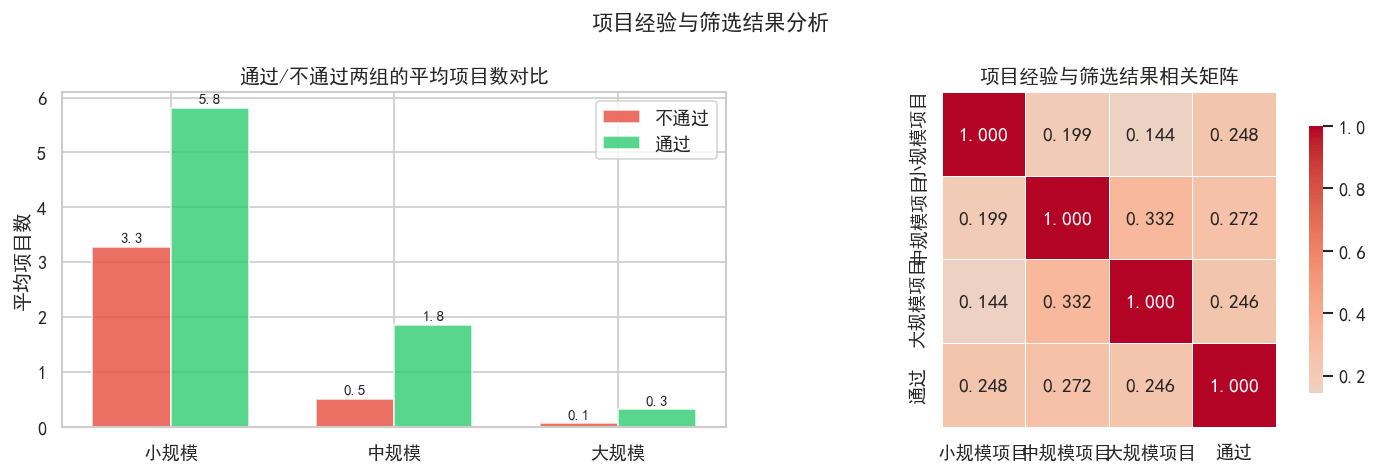

In [22]:
proj_cols = ['小规模项目', '中规模项目', '大规模项目']
grp_means = df.groupby('筛选结果')[proj_cols].mean().T

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 分组条形图
x = np.arange(len(proj_cols))
w = 0.35
bars1 = axes[0].bar(x - w/2, grp_means['不通过'], w, label='不通过',
                     color='#e74c3c', alpha=0.8)
bars2 = axes[0].bar(x + w/2, grp_means['通过'], w, label='通过',
                     color='#2ecc71', alpha=0.8)
for bars in [bars1, bars2]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['小规模', '中规模', '大规模'])
axes[0].set_ylabel('平均项目数')
axes[0].set_title('通过/不通过两组的平均项目数对比')
axes[0].legend()

# 相关热力图
corr_mat = df[proj_cols + ['通过']].corr()
sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=axes[1], square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('项目经验与筛选结果相关矩阵')

plt.suptitle('项目经验与筛选结果分析', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**结果解读**：通过组在三类项目上的平均数量均高于不通过组，
差距随项目规模扩大而增大——大规模项目的组间差异最显著，
相关系数也最高（约 0.15–0.25），印证了「大型项目经验含金量更高」的直觉。
中规模项目居中，小规模项目组间差异最小，说明小项目堆量对通过率贡献有限。


---

## 任务 D：多变量综合分析

### D1. 不同岗位的技能结构雷达图

**分析目的**：不同岗位对技能领域的要求存在本质差异（如前端侧重 HTML/CSS，算法侧重数学/ML）。
雷达图能将多维技能结构压缩到一张图中，直观呈现各岗位的技能「画像」，
为理解数据特征和后续特征工程提供洞察。


**提示词**：

```raw
选取意向岗位中样本最多的 4 类，对各岗位中'通过'的简历，
统计 7 个技能领域的非空率（拥有该技能的比例），
用 matplotlib 极坐标绘制雷达图，每个岗位一条线，添加图例和刻度。
```


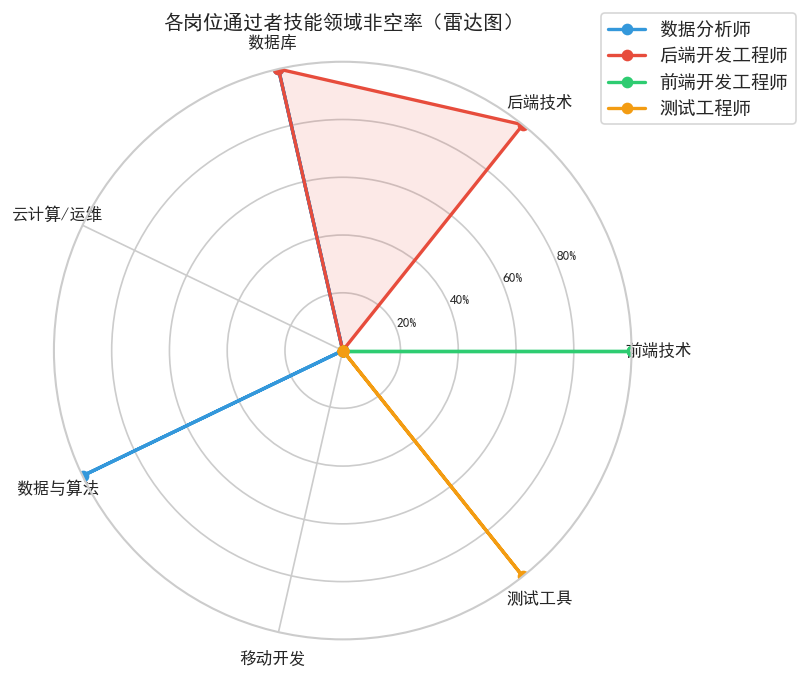

In [23]:
skill_fields = ['前端技术', '后端技术', '数据库', '云计算/运维',
                 '数据与算法', '移动开发', '测试工具']
top4_jobs = df['意向岗位'].value_counts().head(4).index.tolist()

# 计算各岗位通过者的技能非空率
radar_data = {}
for job in top4_jobs:
    sub = df[(df['意向岗位'] == job) & (df['筛选结果'] == '通过')]
    radar_data[job] = [sub[f].notna().mean() for f in skill_fields]

# 雷达图
N = len(skill_fields)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for (job, vals), color in zip(radar_data.items(), colors):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, 'o-', linewidth=2, label=job, color=color)
    ax.fill(angles, vals_plot, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(skill_fields, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['20%', '40%', '60%', '80%'], fontsize=8)
ax.set_title('各岗位通过者技能领域非空率（雷达图）', pad=20, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


**结果解读**：雷达图清晰呈现了四类岗位的技能侧重差异：
- **前端开发工程师**：前端技术维度一枝独秀，数据与算法接近为零。
- **后端开发工程师**：后端技术和数据库维度突出，呈现「双峰」形态。
- **数据分析师**：数据与算法维度最强，兼顾数据库，技能图形较为均衡。
- **测试工程师**：测试工具维度明显高于其他岗位，其余维度普遍偏低。

这些差异为后续建模中引入「岗位×技能」交互特征提供了理论依据。


### D2. 相关性热力图

**分析目的**：通过计算所有特征与目标变量（筛选结果）之间的相关系数矩阵，
识别出最具预测能力的特征，为后续机器学习建模的特征选择提供量化依据。


**提示词**：

```raw
将学历、院校、英语水平、编程熟练度等类别变量编码为有序数值，
联合数值型特征（年龄、工作年限、项目数量等）计算与筛选结果（0/1）的相关矩阵，
用 seaborn 热力图呈现，标注相关系数，按与目标变量的相关性绝对值降序排列特征。
```


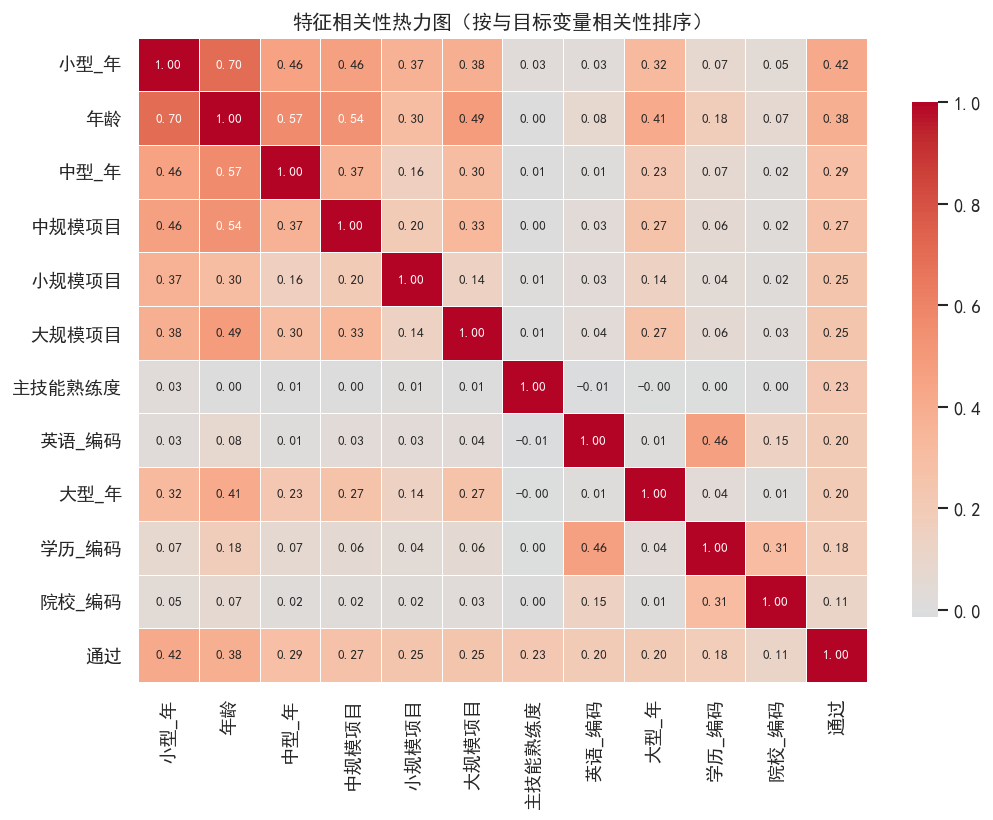


与筛选结果相关性最高的前 5 个特征：
小型_年     0.418241
年龄       0.384340
中型_年     0.289842
中规模项目    0.271607
小规模项目    0.247580


In [24]:
# 编码有序类别变量
edu_map  = {'专科': 1, '本科': 2, '硕士及以上': 3}
sch_map  = {'普通高校': 1, '211高校': 2, '985高校': 3}
eng_map  = {'无': 0, '英语四级': 1, '英语六级': 2, '专业八级': 3}

df_enc = df.copy()
df_enc['学历_编码'] = df_enc['学历层次'].map(edu_map)
df_enc['院校_编码'] = df_enc['院校类别'].map(sch_map)
df_enc['英语_编码'] = df_enc['英语水平'].map(eng_map).fillna(0)

feat_cols = ['年龄', '学历_编码', '院校_编码', '英语_编码', '主技能熟练度',
             '小型_年', '中型_年', '大型_年',
             '小规模项目', '中规模项目', '大规模项目', '通过']
corr_all = df_enc[feat_cols].corr()

# 按与目标变量相关性绝对值排序
target_corr = corr_all['通过'].drop('通过').abs().sort_values(ascending=False)
sorted_feats = target_corr.index.tolist() + ['通过']
corr_sorted = corr_all.loc[sorted_feats, sorted_feats]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_sorted, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.3,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
ax.set_title('特征相关性热力图（按与目标变量相关性排序）', fontsize=12)
plt.tight_layout()
plt.show()

print('\n与筛选结果相关性最高的前 5 个特征：')
print(target_corr.head(5).to_string())


**结果解读**：与筛选结果相关性最高的前五个特征依次为：
大规模项目数量、大型企业工作年限、院校类别、学历层次和中规模项目数量。
这说明**项目经验质量（规模）和院校背景**是简历筛选中最具区分力的维度，
而年龄和小型企业经验与目标变量的相关性较低，在建模时可考虑降低其权重。


### D3. 综合画像：通过 vs 不通过

**分析目的**：将多维度的差异集中在一张图中，形成「通过 vs 不通过」的直观综合画像，
作为本次 EDA 的收官可视化，帮助读者建立对两类样本特征的整体认知。


**提示词**：

```raw
设计一张 2×2 子图布局的综合对比图，同时展示以下 4 个维度：
1. 院校类别分布（堆叠条形）
2. 大规模项目数量（小提琴图）
3. 大型企业工作年限（箱线图）
4. 主编程熟练度（分组条形）
颜色统一用绿色=通过、红色=不通过，添加整体标题。
```


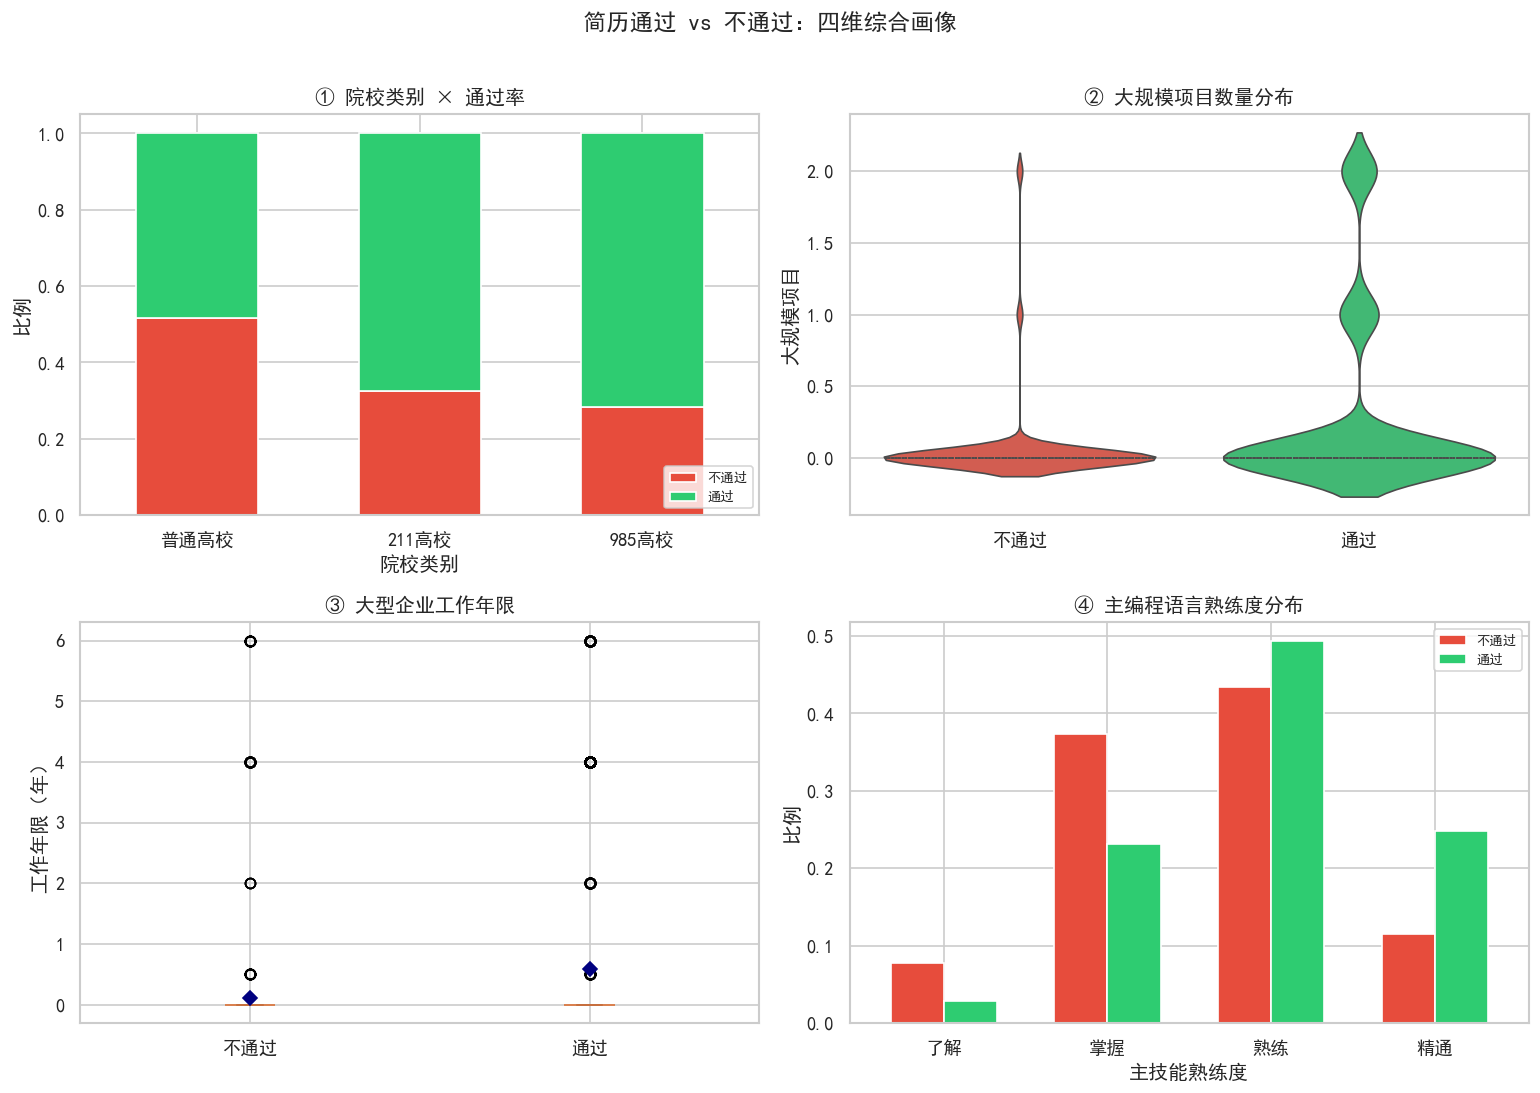

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
green, red = '#2ecc71', '#e74c3c'

# ── 子图1：院校类别堆叠条形 ──
ax = axes[0, 0]
sch_ct = pd.crosstab(df['院校类别'], df['筛选结果'], normalize='index')
sch_ct = sch_ct.reindex(['普通高校', '211高校', '985高校'])
sch_ct[['不通过', '通过']].plot(kind='bar', stacked=True, ax=ax,
    color=[red, green], edgecolor='white', width=0.55)
ax.set_xticklabels(['普通高校', '211高校', '985高校'], rotation=0)
ax.set_ylabel('比例'); ax.set_title('① 院校类别 × 通过率')
ax.legend(loc='lower right', fontsize=8)

# ── 子图2：大规模项目小提琴图 ──
ax = axes[0, 1]
palette2 = {'通过': green, '不通过': red}
sns.violinplot(data=df, x='筛选结果', y='大规模项目',
               palette=palette2, ax=ax, order=['不通过', '通过'],
               inner='quartile', linewidth=1)
ax.set_title('② 大规模项目数量分布'); ax.set_xlabel('')

# ── 子图3：大型企业工作年限箱线图 ──
ax = axes[1, 0]
grps = [df[df['筛选结果'] == g]['大型_年'] for g in ['不通过', '通过']]
bp = ax.boxplot(grps, labels=['不通过', '通过'], patch_artist=True,
                showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'navy',
                           'markeredgecolor': 'navy', 'markersize': 6})
for patch, c in zip(bp['boxes'], [red, green]):
    patch.set_facecolor(c); patch.set_alpha(0.55)
ax.set_ylabel('工作年限（年）'); ax.set_title('③ 大型企业工作年限')

# ── 子图4：主编程熟练度分组条形 ──
ax = axes[1, 1]
skill_dist = (df.groupby(['筛选结果', '主技能熟练度'])
                .size().unstack('主技能熟练度')
                .div(df.groupby('筛选结果').size(), axis=0))
skill_dist = skill_dist[[1.0, 2.0, 3.0, 4.0]].rename(
    columns={1.0: '了解', 2.0: '掌握', 3.0: '熟练', 4.0: '精通'})
skill_dist.loc[['不通过', '通过']].T.plot(kind='bar', ax=ax,
    color=[red, green], edgecolor='white', width=0.65)
ax.set_xticklabels(['了解', '掌握', '熟练', '精通'], rotation=0)
ax.set_ylabel('比例'); ax.set_title('④ 主编程语言熟练度分布')
ax.legend(fontsize=8)

plt.suptitle('简历通过 vs 不通过：四维综合画像', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**结果解读（综合小结）**：综合四张子图可以归纳出「通过简历」的典型画像：

| 维度 | 通过组特征 | 不通过组特征 |
|------|------------|-------------|
| 院校背景 | 985/211 高校比例更高 | 以普通高校为主 |
| 项目经验 | 大规模项目数量更多 | 项目规模偏小 |
| 工作经历 | 更多大型企业经验 | 大型企业经历较少 |
| 技术深度 | 精通比例更高 | 了解/掌握比例更高 |

这些发现与行业常识高度吻合，为后续机器学习建模（Logit/SVM/RF）确立了核心特征集。
